# V5 Changes

## Updated model parameters to improve performance and generalization.

# V4 Changes

## Converted model from pure LSTM to a CNN-LSTM hybrid where the CNN model learns short local EMG patterns inside each window, the LSTM model reads the compressed feature sequence over time, and the final classifier maps the learned representation to gesture classes.

# V3 Changes

## Dropped class 7 from training, validation, and test data. Class 7 has substantially less data than the other labels so it was dropped in this version to investigate whether it had an negative impact on model performance for other labels. 

# V2 Changes

## 1. Fixed class imbalance in DataLoader
## 2. Added dropout in the classifier head
## 3. Used AdamW + weight decay + LR scheduler
## 4. Added gradient clipping 
## 5. Added early stopping based on val loss

## Changes 2-5 were added to address the overfitting seen in v1, where training accuracy goes to 1.0 while validation accuracy plateaus or declines. There was also a class imbalance in that there was a very rare class that occured much less often than others in the data files. The first change aimed to address this by forcing rare classes to show up more frequently in training batches.

# Setup

## Set up notebook environment by importing libraries, defining centralized preprocessing configuration, and building the list of EMG data files to load.

## V3 EDITS: Added class 7 to dropped labels

## V5 EDITS: Increased step size from 25 to 75 to address overfitting.

In [47]:
import os
import json
import math
from pathlib import Path

from __future__ import annotations
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class PreprocessingConfig:
    """
    Stores configuration parameters for data preprocessing.
    """

    # Windowing parameters
    window_size: int = 250

    # Step size for sliding window
    step_size: int = 75 

    # Labels to drop during preprocessing
    drop_label_values: Tuple[int, ...] = (0, 7,)

    # Enforce sorting by time
    sort_by_time: bool = True

# Create an instance of the configuration dataclass
cfg = PreprocessingConfig()

# Root directory containing the data files
root_dir = Path("/Users/tonyliu/Documents/EMGTuner-master/data")

# Build a list of all EMG .txt files in the root directory
DATA_FILES = [str(file) for file in root_dir.rglob("*.txt") if file.name != "README.txt"]


# Load Files

## Load all EMG files into Pandas DataFrames, standarize column names, and concatenate them into one single dataset.

In [48]:
def load_emg_file(path: str | Path) -> pd.DataFrame:
    """
    Load a single EMG data file into a pandas DataFrame.
    """

    path = Path(path)

    # Try common delimiters until finding one that works
    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(path, sep = sep, engine = "python")

            # Require at least two columns
            if len(df.columns) > 1:
                return df
            
        except Exception:
            # If parsing fails, try the next delimiter
            continue
    
    # If none of the delimiters worked, raise an error
    raise ValueError(f"Could not parse file {path} with common delimiters")

def infer_columns(df: pd.DataFrame) -> Dict[str, List[str] | str]:
    """
    Infer the time column, label column, and channel columns from the DataFrame based on common naming conventions and data types.
    """

    # Normalize column names to lowercase
    cols = {c.lower(): c for c in df.columns}

    # Infer time column
    time_col = None
    for name in ["time", "timestamp", "t"]:
        if name in cols:
            time_col = cols[name]
            break
    
    # Assume first column is time if no match
    if time_col is None:
        time_col = df.columns[0] 

    # Infer label column
    label_col = None
    for name in ["label", "class", "target", "gesture"]: 
        if name in cols:
            label_col = cols[name]
            break
    
    # Assume last column is label if no match
    if label_col is None:
        label_col = df.columns[-1]
    
    # Infer channel columns
    chanel_cols = []
    for col in df.columns:
        col_lower = col.lower()
        if col_lower == time_col.lower() or col_lower == label_col.lower():
            continue
        if "channel" in col_lower or col_lower.startswith("ch"):
            chanel_cols.append(col)
    
    # If no channel columns found, assume all non-time, non-label columns are channels
    if len(chanel_cols) == 0:
        possible_channel_cols = [col for col in df.columns if col != time_col and col != label_col]
        numeric_cols = []

        for col in possible_channel_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                numeric_cols.append(col)
        
        chanel_cols = numeric_cols

    # Final sanity check to ensure at least one channel column
    if len(chanel_cols) == 0:
        raise ValueError("Could not infer any channel columns")
    
    return {"time_col": time_col, "label_col": label_col, "channel_cols": chanel_cols}

all_dfs = []
schemas = []

# Iterate over each data file
for file in DATA_FILES:
    # Load the data file into a DataFrame
    df = load_emg_file(file)

    # Identify columns dynamically
    info = infer_columns(df)

    # Standardize column names
    time_col = info["time_col"]
    label_col = info["label_col"]
    channel_cols = info["channel_cols"]

    # Reorder columns to have time first, then channels, then label
    cols = [time_col] + channel_cols + [label_col]
    df = df[cols].copy()
    df = df.rename(columns = {time_col: "time", label_col: "label"})
    channels = [col for col in df.columns if col not in ["time", "label"]]
    df = df[["time"] + channels + ["label"]]

    # Add metadata columns for source file and original index
    df["source_file"] = str(file)
    df["source_index"] = np.arange(len(df), dtype = np.int64)

    # Sort by time if configured to do so
    if cfg.sort_by_time:
        df = df.sort_values("time", kind = "mergesort").reset_index(drop = True)
    
    # Append the processed DataFrame to the list and store schema information
    all_dfs.append(df)
    schemas.append({
        "file": str(file),
        "num_rows": len(df),
        "channels": channels,
        "time_dtype": str(df["time"].dtype),
        "label_dtype": str(df["label"].dtype),
        "n_channels": len(channels),
    })

# Concatenate all DataFrames into a single DataFrame
raw_df = pd.concat(all_dfs, ignore_index = True)

# Create a DataFrame to summarize the schema of each file 
schemas_df = pd.DataFrame(schemas)

# Apply Filters

## Apply signal-processing filters to EMG channels.

In [49]:
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

def calculate_sampling_rate(time_series: np.ndarray) -> float:
    """
    Calculate the sampling rate (in Hz) from a time series of timestamps (in milliseconds).
    """

    # Convert to numpy array
    t = np.asarray(time_series, dtype = np.float64)
    dt_ms = np.median(np.diff(t))

    # Guard against non-positive time differences 
    if dt_ms <= 0:
        raise ValueError("Non-positive time differences found, cannot calculate sampling rate")
    
    # Calculate sampling frequency in Hz
    fs = 1000.0 / dt_ms
    return float(fs)

# Calculate sampling rate for each file
fs_by_file = {}
for src, sub in raw_df.groupby("source_file", sort = False):
    fs_by_file[src] = calculate_sampling_rate(sub["time"].to_numpy())

def design_bandpass_filter(fs: float, low_hz = 20.0, high_hz = 450.0, order = 4):
    """
    Design a Butterworth bandpass filter using second-order sections (SOS) for stability. 
    """

    # Calculate normalized cutoff frequencies
    nyquist = 0.5 * fs
    low = low_hz / nyquist
    high = high_hz / nyquist

    # Guard against invalid cutoff frequencies
    if not (0 < low < 1 and 0 < high < 1):
        raise ValueError("Invalid cutoff frequencies for bandpass filter")

    # Design the Butterworth bandpass filter and return the second-order sections for stability
    sos = butter(order, [low, high], btype = "bandpass", output = "sos")
    return sos

def apply_bandpass_filter(X: np.ndarray, fs: float, low_hz = 20.0, high_hz = 450.0, order = 4) -> np.ndarray:
    """
    Apply a Butterworth bandpass filter to the input data X using zero-phase filtering (filtfilt) to avoid phase distortion. 
    """

    # Design the bandpass filter
    sos = design_bandpass_filter(fs, low_hz, high_hz, order)
    
    # Apply the filter along the appropriate axis depending on the shape of X (2D: samples x channels, 3D: samples x time x channels)
    if X.ndim == 2:
        return sosfiltfilt(sos, X, axis = 0).astype(np.float32)
    elif X.ndim == 3:
        return sosfiltfilt(sos, X, axis = 1).astype(np.float32)
    else:
        raise ValueError("Input data must be 2D or 3D array")

def apply_notch_filter(X: np.ndarray, fs: float, notch_hz = 60.0, quality_factor = 30.0) -> np.ndarray:
    """
    Apply a notch filter to the input data X to remove powerline interference at the specified notch frequency (in Hz). 
    The filter is applied using zero-phase filtering (filtfilt) to avoid phase distortion.
    """

    # Design the notch filter
    nyquist = 0.5 * fs
    w0 = notch_hz / nyquist

    # Guard against invalid notch frequencies
    if not (0 < w0 < 1):
        raise ValueError("Invalid notch frequency for notch filter")
    
    # Design the notch filter coefficients
    b, a = iirnotch(w0, quality_factor)

    # Apply the notch filter along the appropriate axis depending on the shape of X (2D: samples x channels, 3D: samples x time x channels)
    if X.ndim == 2:
        return filtfilt(b, a, X, axis = 0).astype(np.float32)
    elif X.ndim == 3:
        return filtfilt(b, a, X, axis = 1).astype(np.float32)
    else:
        raise ValueError("Input data must be 2D or 3D array")

def filter_emg_data(df: pd.DataFrame, channel_cols: list[str], notch_hz = 60.0) -> pd.DataFrame:
    """
    Filter EMG data in the DataFrame df for the specified channel columns using a notch filter to remove powerline interference and a bandpass filter to isolate the desired frequency range.
    """
    
    # Create a copy of the DataFrame to store filtered results
    filtered = df.copy()

    # Apply filters separately for each source file to account for different sampling rates and characteristics
    for src, sub_idx in filtered.groupby("source_file", sort = False).groups.items():
        # Extract the subset of data for the current source file and get its sampling rate
        sub = filtered.loc[sub_idx]
        fs = fs_by_file[src]

        # Extract the signal data for the channel columns and convert to numpy array
        sig = sub[channel_cols].to_numpy(dtype = np.float32)
        sig = apply_notch_filter(sig, fs, notch_hz)
        sig = apply_bandpass_filter(sig, fs, low_hz = 20.0, high_hz = min(450.0, 0.45 * fs))

        # Update the filtered signal back into the DataFrame
        filtered.loc[sub_idx, channel_cols] = sig
    
    return filtered

# Apply the filtering pipeline to the raw DataFrame to obtain a new DataFrame with filtered EMG signals in the channel columns
filtered_df = filter_emg_data(raw_df, channel_cols)


# Check for Invalid Labels

## Check for missing labels that can break segmentation, label encoding, and loss computation.

In [50]:
def report_nan_labels(df: pd.DataFrame):
    """
    Report the number of rows in the DataFrame that have NaN labels, and break down the count by source file.
    """

    # Identify rows with NaN labels
    bad = df[df["label"].isna()]
    print("Total rows:", len(df))
    print("Rows with NaN label:", len(bad))

    # If there are any rows with NaN labels, print a breakdown of how many come from each source file and display a sample of the bad rows for inspection
    if len(bad) > 0:
        print("\nNaN label rows by file:")
        print(bad["source_file"].value_counts())
        display(bad.head(10))

# Report on the presence of NaN labels in the filtered DataFrame to identify any issues with missing labels after filtering
report_nan_labels(filtered_df)

Total rows: 4237908
Rows with NaN label: 1

NaN label rows by file:
source_file
/Users/tonyliu/Documents/EMGTuner-master/data/34/1_raw_data_10-51_07.04.16.txt    1
Name: count, dtype: int64


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,label,source_file,source_index
522178,97144,0.000001,-6.391834e-07,-0.000006,-9.419580e-07,-7.347777e-07,0.000002,-4.296082e-07,2.338881e-07,NaN,/Users/tonyliu/Documents/EMGTuner-master/data/...,79764


# Re-Segment and Window

## Convert continous EMG recordings into fixed length training samples using label-based segmentation and a sliding window.

In [51]:
def segment_by_label(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    Segment the DataFrame into contiguous segments where the label is constant, grouping by source file to ensure segments do not cross file boundaries. 
    """

    segments = []
    
    # Group by source file to ensure segments do not cross file boundaries
    for _, sub in df.groupby("source_file", sort = False):
        # Reset index for the current subset to ensure proper alignment when identifying label changes
        sub = sub.reset_index(drop = True)

        # Identify where the label changes compared to the previous row, treating the first row as a change point. 
        # Then take the cumulative sum of these change points to assign a unique segment ID to each contiguous segment of constant labels
        change = sub["label"].ne(sub["label"].shift(1)).fillna(True)
        segment_ids = change.cumsum()

        # Group by the segment IDs to extract each contiguous segment of constant labels and append it to the list as a separate DataFrame
        for _, segment in sub.groupby(segment_ids, sort = False):
            segments.append(segment.reset_index(drop = True))
    
    return segments

def make_windows_from_segment(segment: pd.DataFrame, channel_cols: list[str], cfg: PreprocessingConfig) -> Tuple[np.ndarray, np.ndarray]:
    """
    Make sliding windows of data from a single segment DataFrame, where the label is constant. 
    """

    # Extract the signal data for the channel columns and convert to numpy array and get the label for this segment
    data = segment[channel_cols].to_numpy(dtype = np.float32)
    label = int(segment["label"].iloc[0])
    T, C = data.shape

    # If the segment is shorter than the window size, cannot create any windows, so return empty arrays
    if T < cfg.window_size:
        return np.empty((0, cfg.window_size, C), dtype = np.float32), np.empty((0,), dtype = np.int64)
    
    # Create sliding windows of the data and create a corresponding array of labels for each window
    starts = np.arange(0, T - cfg.window_size + 1, cfg.step_size, dtype = np.int64)
    X = np.stack([data[start : start + cfg.window_size] for start in starts], axis = 0)
    y = np.full((len(starts),), label, dtype = np.int64)
    return X, y

# Report on the presence of NaN labels in the filtered DataFrame 
before = len(filtered_df)
filtered_df = filtered_df.dropna(subset = ["label"]).reset_index(drop = True)
after = len(filtered_df)
print(f"Dropped {before - after} rows with NaN label.")

# Segment the filtered DataFrame into contiguous segments of constant labels
segments = segment_by_label(filtered_df)

X_list, y_list, file_list = [], [], []

# For each segment, create sliding windows of the signal data and corresponding labels
for segment in segments:
    # Get the label for this segment 
    label = int(segment["label"].iloc[0])

    # If the label for this segment is in the list of labels to drop, skip this segment and do not create windows from it
    if label in cfg.drop_label_values:
        continue

    # Create sliding windows from this segment
    X_seg, y_seg = make_windows_from_segment(segment, channel_cols, cfg)

    # If no windows were created from this segment, skip adding it to the dataset
    if len(y_seg) == 0:
        continue

    # Append the windows and labels from this segment to the overall dataset lists and keep track of the source file for each window 
    X_list.append(X_seg)
    y_list.append(y_seg)
    file_list.extend([segment["source_file"].iloc[0]] * len(y_seg))

# After processing all segments, concatenate the lists of windows and labels into single numpy arrays for X and y
X = np.concatenate(X_list, axis = 0)
y = np.concatenate(y_list, axis = 0)

# Convert the list of source files into a numpy array
files = np.array(file_list)

# Print the final shape of the dataset and the distribution of labels in the windows
print(f"Final dataset shape: X={X.shape}, y={y.shape}")
print("Window label distribution:\n", pd.Series(y).value_counts().sort_index())

Dropped 1 rows with NaN label.
Final dataset shape: X=(17574, 250, 8), y=(17574,)
Window label distribution:
 1    2932
2    2841
3    2927
4    2949
5    2957
6    2968
Name: count, dtype: int64


# Train/Validation/Test Split Without Leakage

## Split the dataset into train/validation/test in a way that prevents leakage by ensuring windows from the same file do not appear in multiple splits.

In [52]:
from sklearn.model_selection import train_test_split

def split_by_file(files: np.ndarray, train_size = 0.7, val_size = 0.15, test_size = 0.15, random_state = 42) -> Tuple[set[str], set[str], set[str]]:
    """
    Split the dataset into training, validation, and test sets based on unique source files to ensure that all windows from the same file are in the same split. 
    The split is done in a stratified manner to maintain the distribution of labels across splits, and the random state is set for reproducibility.
    """
    
    # Get unique source files
    unique_files = np.unique(files)

    # Split the unique files into a training set and a temporary set (which will be further split into validation and test sets)
    train_files, temp_files = train_test_split(unique_files, test_size = 1 - train_size, random_state = random_state, shuffle = True)

    # Split the temporary set of files into validation and test sets using the specified validation and test sizes
    val_files, test_files = train_test_split(temp_files, test_size = test_size / (test_size + val_size), random_state = random_state, shuffle = True)
    return set(train_files), set(val_files), set(test_files)

# Split the dataset into training, validation, and test sets
train_files, val_files, test_files = split_by_file(files)

# Create boolean masks for the training, validation, and test sets based on the source files
train_mask = np.array([f in train_files for f in files])
val_mask = np.array([f in val_files for f in files])
test_mask = np.array([f in test_files for f in files])

# Use the boolean masks to index into the X and y arrays to create the final training, validation, and test datasets, ensuring that all windows from the same source file are in the same split
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Print the shapes of the training, validation, and test datasets, as well as the number of unique source files in each split
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train files:", len(train_files), "Val files:", len(val_files), "Test files:", len(test_files))

Train: (12280, 250, 8) Val: (2578, 250, 8) Test: (2716, 250, 8)
Train files: 50 Val files: 11 Test files: 11


# Encode Labels Dynamically

## Convert raw label values into consecutive class indices (0...K-1) required by PyTorch classification.

In [53]:
def create_label_mapping(labels: np.ndarray) -> Dict[int, int]:
    """
    Create a mapping from original label values to integer indices starting from 0. 
    This is useful for encoding the labels into a format suitable for machine learning models, which typically require integer class labels. 
    The mapping is created based on the unique label values present in the training set to ensure that the model only learns from the labels it has seen during training.
    """

    # Retrieve and sort unique labels
    unique_labels = np.sort(np.unique(labels))

    # Create mapping from label values to integer indices starting from 0
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    return label_to_index

# Create a label mapping based on the unique labels in the training set
label_map = create_label_mapping(y_train)

# Create an inverse mapping for use in decoding predictions back to original label values
inv_label_map = {idx: label for label, idx in label_map.items()}

def encode_labels(labels: np.ndarray, label_map: Dict[int, int]) -> np.ndarray:
    """
    Encode the original label values into integer indices using the provided label mapping.
    """

    return np.array([label_map[label] for label in labels], dtype = np.int64)

# Encode the labels in the training, validation, and test sets
y_train_encoded = encode_labels(y_train, label_map)
y_val_encoded = encode_labels(y_val, label_map)
y_test_encoded = encode_labels(y_test, label_map)

# Print the number of unique classes and the label mapping
num_classes = len(label_map)
print("num_classes:", num_classes)
print("label_map:", label_map)

num_classes: 6
label_map: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5}


# Normalize

## Normalize EMG channels so each channel has a consistent scale. This improves training stability and helps the model learn patterns instead of absolute magnitudes.

In [54]:
def fit_channel_standardizer(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fit a channel-wise standardizer to the input data X by calculating the mean and standard deviation for each channel across all samples and time steps.
    """

    # Reshape the data to combine the samples and time steps into a single dimension
    flat = X.reshape(-1, X.shape[-1])

    # Calculate the mean and standard deviation for each channel, adding a small epsilon to the standard deviation to prevent division by zero during standardization.
    mean = np.mean(flat, axis = 0)
    std = np.std(flat, axis = 0) + 1e-8
    return mean.astype(np.float32), std.astype(np.float32)

def apply_channel_standardization(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """
    Apply channel-wise standardization to the input data X using the provided mean and standard deviation for each channel.
    """

    return ((X - mean[None, None, :]) / std[None, None, :]).astype(np.float32)

# Fit the channel standardizer on the training data
mean_std = fit_channel_standardizer(X_train)

# Apply the channel standardization to the training, validation, and test sets
X_train_n = apply_channel_standardization(X_train, *mean_std)
X_val_n = apply_channel_standardization(X_val, *mean_std)
X_test_n = apply_channel_standardization(X_test, *mean_std)

# Print the shapes of the normalized training, validation, and test datasets
print("Normalized shapes:", X_train_n.shape, X_val_n.shape, X_test_n.shape)

Normalized shapes: (12280, 250, 8) (2578, 250, 8) (2716, 250, 8)


# Create Custom Dataset

## Wrap the windowed EMG arrays and labels into a PyTorch Dataset so they can be efficiently loaded in batches during training.

In [55]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class EMGWindowsDataset(Dataset):
    """
    A PyTorch Dataset for EMG windows.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        """
        Initialize the EMGWindowsDataset with input data X and labels y.
        """
        
        # Check that X and y have the same number of samples to ensure that each window has a corresponding label
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        # Convert the input data X and labels y from numpy arrays to PyTorch tensors
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.long)
    
    def __len__(self):
        """
        Return the number of samples in the dataset, which is determined by the length of the labels tensor.
        """

        return len(self.y)
    
    def __getitem__(self, idx):
        """
        Return the input data and label for the sample at the specified index idx. 
        """

        return self.X[idx], self.y[idx]

# Create DataLoaders

## Create PyTorch DataLoaders to batch and shuffle data during training and evaluation.

## V2 EDIT: Added a weighted random sampler to address class imbalance.

## V5 EDIT: Removed the use of WeightedRandomSample due to no class imbalance after dropping label 7.

In [56]:
# Create PyTorch Datasets and DataLoaders for the training, validation, and test sets
batch_size = 64

train_dataset = EMGWindowsDataset(X_train_n, y_train_encoded)
val_dataset = EMGWindowsDataset(X_val_n, y_val_encoded)
test_dataset = EMGWindowsDataset(X_test_n, y_test_encoded)

# Calculate class counts from the encoded training labels
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
class_counts = torch.bincount(y_train_tensor, minlength=num_classes).float()
class_counts = torch.clamp(class_counts, min=1.0)

# Create moderated class weights
# Using inverse sqrt is usually more stable than a full inverse
class_weights = 1.0 / torch.sqrt(class_counts)

# Normalize weights so their mean is 1
class_weights = class_weights / class_weights.mean()

# Standard shuffled training loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Validation and test loaders
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())

Train batches: 192
Val batches: 41
Test batches: 43
Class counts: [2027.0, 1985.0, 2033.0, 2074.0, 2077.0, 2084.0]
Class weights: [1.0047270059585571, 1.0153007507324219, 1.003243327140808, 0.9932774305343628, 0.9925598502159119, 0.9908915162086487]


# Extract Dynamic Model Parameters

## Automatically derive key model parameters from the prepared data so the model matches the dataset.

In [57]:
# Extract the number of channels, sequence length, and number of classes from the training data 
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]
num_classes = len(np.unique(y_train_encoded))

# Print the number of channels, sequence length, and number of classes 
print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

num_channels: 8
sequence_length: 250
num_classes: 6


# Define CNN-LSTM Classifier

## Define the CNN-LSTM nerual network used to classify each EMG window into a gesture class.

## V2 EDIT: Added dropout in the final classifier to reduce overfitting.

## V4 EDIT: Converted from pure LSTM to CNN-LSTM hyrbid.

In [ ]:
import torch.nn as nn

class CNNLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        conv_channels: list[int] | tuple[int, ...] = (64, 128),
        kernel_size: int = 7,
        lstm_hidden_size: int = 128,
        lstm_num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
    ):
        """
        Initiate the CNNLSTMClassifier with the specified architecture parameters, including the input size (number of channels), number of output classes, convolutional layer configuration, LSTM configuration, dropout rate, and whether to use bidirectional LSTMs.
        """
        
        # Call the superclass constructor to initialize the nn.Module
        super().__init__()

        # Store the parameters as instance variables
        self.input_size = input_size
        self.num_classes = num_classes
        self.conv_channels = list(conv_channels)
        self.kernel_size = kernel_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers = lstm_num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional

        # CNN expects shape: (batch, channels, time)
        conv_layers = []
        in_channels = input_size

        # Build the convolutional layers based on the specified configuration
        for i, out_channels in enumerate(self.conv_channels):
            # Each convolutional layer consists of a Conv1d, followed by BatchNorm1d, ReLU activation, and MaxPool1d to reduce the temporal dimension. 
            conv_layers.extend([
                nn.Conv1d(
                    in_channels = in_channels,
                    out_channels = out_channels,
                    kernel_size = kernel_size,
                    padding = kernel_size // 2
                ),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5)
            ])

            # Only pool once, after the first conv block,
            # so we reduce sequence length without throwing away too much timing information.
            if i == 0:
                conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=2))

            # Update in_channels for the next layer to be the out_channels of the current layer
            in_channels = out_channels
        
        # Combine the convolutional layers into a sequential module
        self.cnn = nn.Sequential(*conv_layers)

        # LSTM input size becomes the final number of CNN output channels
        self.lstm = nn.LSTM(
            input_size = in_channels,
            hidden_size = lstm_hidden_size,
            num_layers = lstm_num_layers,
            batch_first = True,
            dropout = dropout if lstm_num_layers > 1 else 0.0,
            bidirectional = bidirectional
        )

        lstm_output_size = lstm_hidden_size * (2 if bidirectional else 1)

        # avg pool + max pool => 2 * lstm_output_size
        self.head = nn.Sequential(
            nn.Linear(lstm_output_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, num_channels)

        # CNN expects (batch, channels, time)
        x = x.transpose(1, 2)

        # CNN feature extraction
        x = self.cnn(x)

        # Back to LSTM shape: (batch, seq_len, features)
        x = x.transpose(1, 2)

        # LSTM output for every time step
        lstm_out, _ = self.lstm(x)

        # Global average pooling over time
        avg_pool = torch.mean(lstm_out, dim=1)

        # Global max pooling over time
        max_pool, _ = torch.max(lstm_out, dim=1)

        # Combine both summaries
        features = torch.cat([avg_pool, max_pool], dim=1)

        logits = self.head(features)
        return logits

# Instantiate the Model

## Create an instance of the CNN-LSTM model using the dataset-derived dimensions and chosen hyperparameters.

## V4 EDIT: Updated parameters for CNN-LSTM

In [59]:
# Extract the number of channels and sequence length
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]

print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

# CNN-LSTM hyperparameters
conv_channels = [64, 128]
kernel_size = 7
lstm_hidden_size = 128
lstm_num_layers = 2
dropout = 0.3
bidirectional = True

# Instantiate CNN-LSTM model
model = CNNLSTMClassifier(
    input_size=num_channels,
    num_classes=num_classes,
    conv_channels=conv_channels,
    kernel_size=kernel_size,
    lstm_hidden_size=lstm_hidden_size,
    lstm_num_layers=lstm_num_layers,
    dropout=dropout,
    bidirectional=bidirectional
)

num_channels: 8
sequence_length: 250
num_classes: 6


# Create Device, Loss Function, and Optimizer

## Configure training compoents: move the model to CPU/GPU, define the classification loss, and choose an optimizer to update weights.

## V2 EDITS: Used AdamW and LR scheduler instead of Adam to improve generalization.

## V5 EDITS: Change optimizer and scheduler parameters to improve performance.

In [ ]:
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Classes are already close to balanced, so use plain cross-entropy
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 3e-4,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.5,
    patience = 3,
    min_lr = 1e-6
)

print("Using device:", device)

Using device: cpu


# Sanity Check

## Run a quick forward pass on one batch to verify shapes, data types, and that the model can produce outputs without crashing.

In [61]:
# Test the forward pass of the model with a single batch of data from the training DataLoader
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)
logits = model(X_batch)

# Print the shapes of the input batch, labels, and output logits
print("X_batch:", X_batch.shape)   
print("y_batch:", y_batch.shape)    
print("logits:", logits.shape) 

X_batch: torch.Size([64, 250, 8])
y_batch: torch.Size([64])
logits: torch.Size([64, 6])


# Training and Validation Utilities

## Define reusable helper functions for training and validation.

## V2 EDITS: Added gradient clipping to stabilize LSTM training.

In [62]:
def train_one_epoch(model: nn.Module, dataloader: DataLoader, criterion, optimizer, device) -> dict:
    """
    Train the model for one epoch using the provided DataLoader, loss function, optimizer, and device.
    """

    # Set the model to training mode to enable dropout and other training-specific behaviors
    model.train()

    # Initialize variables to track the total loss, number of correct predictions, and total number of samples
    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    # Iterate over the batches of data from the DataLoader
    for X_batch, y_batch in dataloader:
        # Move the input data and labels to the specified device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Zero the gradients of the optimizer to prevent accumulation of gradients from previous batches
        optimizer.zero_grad()

        # Perform the forward pass of the model to obtain the logits for the current batch
        logits = model(X_batch)

        # Compute the loss by comparing the logits to the true labels using the specified loss function
        loss = criterion(logits, y_batch)

        # Perform the backward pass to compute the gradients of the loss with respect to the model parameters
        loss.backward()

        # Clip the gradients to a maximum norm of 1.0 to prevent exploding gradients and improve training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)

        # Take an optimization step to update the model parameters based on the computed gradients
        optimizer.step()

        # Update the total loss by adding the loss for the current batch multiplied by the batch size
        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        # Calculate the predicted class labels by taking the argmax of the logits along the class dimension
        preds = torch.argmax(logits, dim = 1)

        # Update the total number of correct predictions by comparing the predicted labels to the true labels and summing the number of matches and update the total count of samples by adding the batch size
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "accuracy": total_correct / total_count}

@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, criterion, device) -> dict:
    """
    Evaluate the model on a given dataset using the provided DataLoader, loss function, and device.
    """
    
    # Set the model to evaluation mode to disable dropout and other training-specific behaviors
    model.eval()

    # Initialize variables to track the total loss, number of correct predictions, and total number of samples 
    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    # Iterate over the batches of data from the DataLoader
    for X_batch, y_batch in dataloader:
        # Move the input data and labels to the specified device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Perform the forward pass of the model to obtain the logits for the current batch
        logits = model(X_batch)

        # Compute the loss by comparing the logits to the true labels using the specified loss function
        loss = criterion(logits, y_batch)

        # Update the total loss by adding the loss for the current batch multiplied by the batch size
        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        # Calculate the predicted class labels by taking the argmax of the logits along the class dimension
        preds = torch.argmax(logits, dim = 1)

        # Update the total number of correct predictions by comparing the predicted labels to the true labels and summing the number of matches and update the total count of samples by adding the batch size
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "accuracy": total_correct / total_count}
        


# Full Training Loop

## Train the model for multiple epochs while tracking validation performance and saving the best model weights.

## V2 EDITS: Added an early stopping mechanism and utilized a learning rate scheduler to address overfitting and improve generalization.

## V5 EDITS: Increased patience for model to benefit from lower learning rate.

In [63]:
import copy
import math

# Set up model training parameters
max_epochs = 200
patience = 12
best_val_loss = math.inf
best_model_state = None
epochs_no_improve = 0
history = []

# Train the model for a maximum number of epochs
for epoch in range(1, max_epochs + 1):
    # Train the model for one epoch and compute the training metrics
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate the model on the validation set to compute the validation metrics
    val_metrics = evaluate(model, val_loader, criterion, device) if len(val_loader) > 0 else None

    # Record the metrics for this epoch in the history list, including the epoch number, training loss, training accuracy, and if validation metrics are available, the validation loss and validation accuracy
    row = {"epoch": epoch, "train_loss": train_metrics["loss"], "train_accuracy": train_metrics["accuracy"]}

    # If validation metrics are available, add them to the row dictionary
    if val_metrics is not None:
        row["val_loss"] = val_metrics["loss"]
        row["val_accuracy"] = val_metrics["accuracy"]

        # Step the learning rate scheduler using the validation loss to determine if the learning rate should be reduced
        scheduler.step(val_metrics["loss"])

        # Check if the validation loss has improved by at least 1e-4 compared to the best validation loss seen so far
        # If it has improved, update the best validation loss, save a copy of the current model state as the best model state, and reset the epochs_no_improve counter to 0
        if val_metrics["loss"] < best_val_loss - 1e-3:
            best_val_loss = val_metrics["loss"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        
        # If it has not improved, increment the epochs_no_improve counter by 1.
        else:
            epochs_no_improve += 1
        
        # Print the training and validation metrics for this epoch
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}, "
            f"Val Loss={val_metrics['loss']:.4f}, Val Acc={val_metrics['accuracy']:.4f}, "
            f"NoImprove={epochs_no_improve}/{patience}"
        )

        # If the number of epochs with no improvement in validation loss has reached the specified patience, print a message indicating that early stopping has been triggered and break out of the training loop to stop training the model
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement")
            break
    
    # If validation metrics are not available, just print the training metrics for this epoch
    else:
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}"
        )

    # Append the row of metrics for this epoch to the history list
    history.append(row)

Epoch 1: Train Loss=0.9740, Train Acc=0.5923, Val Loss=0.6742, Val Acc=0.7661, NoImprove=0/12
Epoch 2: Train Loss=0.4964, Train Acc=0.8183, Val Loss=0.4785, Val Acc=0.8456, NoImprove=0/12
Epoch 3: Train Loss=0.4197, Train Acc=0.8404, Val Loss=0.4755, Val Acc=0.8421, NoImprove=0/12
Epoch 4: Train Loss=0.3670, Train Acc=0.8589, Val Loss=0.4655, Val Acc=0.8538, NoImprove=0/12
Epoch 5: Train Loss=0.3320, Train Acc=0.8731, Val Loss=0.5373, Val Acc=0.8231, NoImprove=1/12
Epoch 6: Train Loss=0.2934, Train Acc=0.8884, Val Loss=0.4810, Val Acc=0.8507, NoImprove=2/12
Epoch 7: Train Loss=0.2729, Train Acc=0.8943, Val Loss=0.5519, Val Acc=0.8417, NoImprove=3/12
Epoch 8: Train Loss=0.2581, Train Acc=0.8985, Val Loss=0.5062, Val Acc=0.8367, NoImprove=4/12
Epoch 9: Train Loss=0.2144, Train Acc=0.9190, Val Loss=0.4421, Val Acc=0.8604, NoImprove=0/12
Epoch 10: Train Loss=0.2021, Train Acc=0.9265, Val Loss=0.4315, Val Acc=0.8701, NoImprove=0/12
Epoch 11: Train Loss=0.1856, Train Acc=0.9303, Val Loss=0.4

# Load Best Model Weights

## Restore the best-performing model parameters found during training before testing.

In [64]:
# After training is complete, if a best model state was saved based on validation loss, load that best model state back into the model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded Best Model With Best Val Loss={best_val_loss:.4f}")

Loaded Best Model With Best Val Loss=0.3888


# Evaluate on Test Set

## Compute final loss and accuracy on the held-out test set using the best model weights.

In [65]:
# Evaluate the final model on the test set
test_metrics = evaluate(model, test_loader, criterion, device)

# Print results
print(f"Test Loss={test_metrics['loss']:.4f}, Test Acc={test_metrics['accuracy']:.4f}")

Test Loss=0.5126, Test Acc=0.8630


# Evaluate Model Performance

## Produce deeper evaluation outputs to understand where the model succeeds or fail.

              precision    recall  f1-score   support

           0     0.9914    0.9914    0.9914       467
           1     0.9728    0.8973    0.9335       438
           2     0.7464    0.9069    0.8188       451
           3     0.7773    0.8591    0.8162       447
           4     0.8794    0.8122    0.8445       458
           5     0.8500    0.7099    0.7737       455

    accuracy                         0.8630      2716
   macro avg     0.8696    0.8628    0.8630      2716
weighted avg     0.8699    0.8630    0.8633      2716



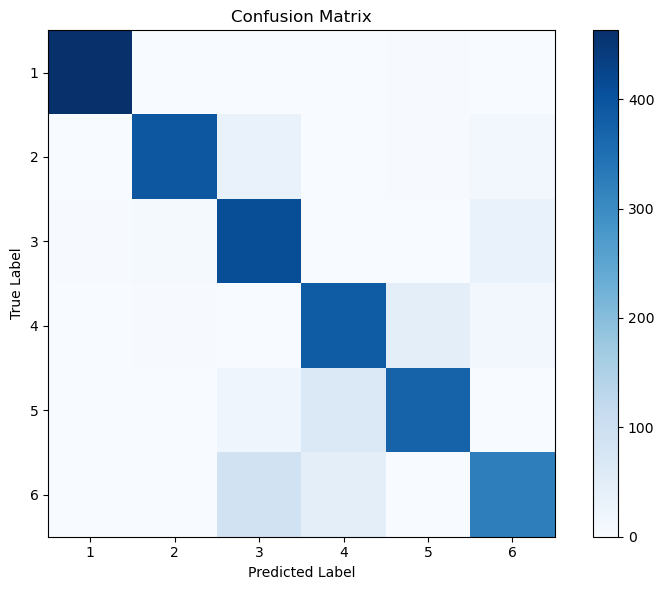

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def evaluate_full(model: nn.Module, dataloader: DataLoader, device):
    """
    Evaluate the model on the entire dataset and return the true labels and predicted labels for all samples. 
    """

    # Set the model to evaluation mode to disable dropout and other training-specific behaviors
    model.eval()

    # Initialize lists to store the predicted labels and true labels for all samples in the dataset
    all_preds = []
    all_labels = []

    # Iterate over the batches of data from the DataLoader
    for X_batch, y_batch in dataloader:
        # Move the input data to the specified device
        X_batch = X_batch.to(device)

        # Perform the forward pass of the model to obtain the logits for the current batch
        logits = model(X_batch)

        # Calculate the predicted class labels by taking the argmax of the logits along the class dimension, and move the predicted labels back to the CPU and convert them to a numpy array for further analysis
        preds = torch.argmax(logits, dim = 1).cpu().numpy()

        # Append the predicted labels and true labels for this batch to the respective lists
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())
    
    return np.concatenate(all_labels), np.concatenate(all_preds)

# Evaluate the model on the test set to obtain the true labels and predicted labels for all samples
y_true, y_pred = evaluate_full(model, test_loader, device)

# Print the classification report
print(classification_report(y_true, y_pred, digits = 4))

# Plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize = (8, 6))
plt.imshow(cm, interpolation = "nearest", cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [inv_label_map[i] for i in range(num_classes)])
plt.yticks(tick_marks, [inv_label_map[i] for i in range(num_classes)])
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Check Class Imbalance

## Inspect how many samples exist per class in the training set to identify imbalance that could hurt performance.

In [67]:
# Print the distribution of encoded labels in the training set 
print(pd.Series(y_train_encoded).value_counts().sort_index())

0    2027
1    1985
2    2033
3    2074
4    2077
5    2084
Name: count, dtype: int64


# Plot Training Curves

## Visualize training/validation loss and accuracy across epochs to diagnose overfitting or underfitting.

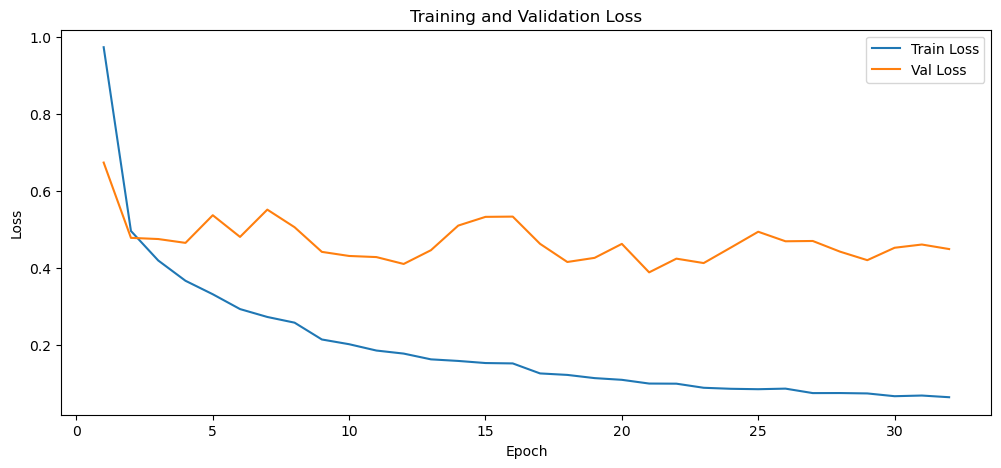

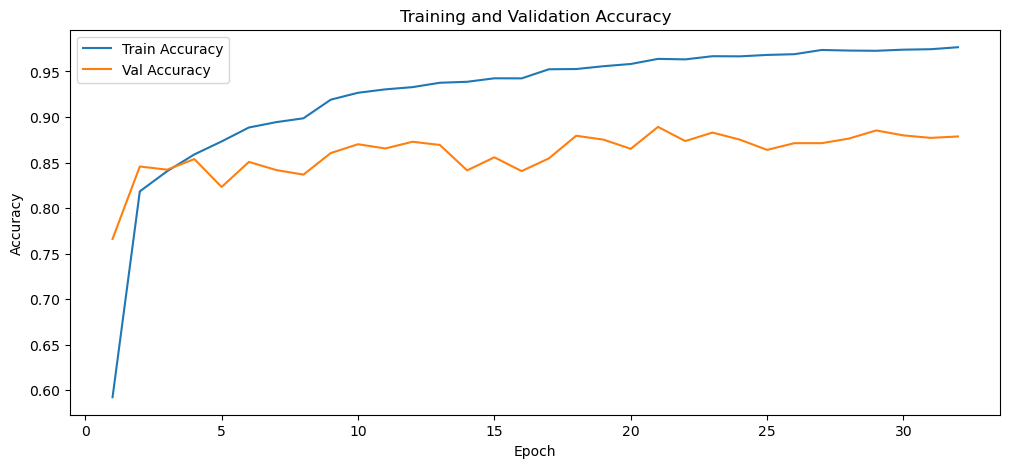

In [68]:
# Convert the training history into a DataFram
hist = pd.DataFrame(history)

# Plot the training and validation loss over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_loss"], label = "Train Loss")
if "val_loss" in hist.columns:
    plt.plot(hist["epoch"], hist["val_loss"], label = "Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# Plot the training and validation accuracy over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_accuracy"], label = "Train Accuracy")
if "val_accuracy" in hist.columns:
    plt.plot(hist["epoch"], hist["val_accuracy"], label = "Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

# Save the Model

## Save the trained model and the preprocessing metadata needed to correctly use it later.

In [69]:
# Save the best model state and metadata to the artifacts directory 
out = Path("artifacts")
out.mkdir(exist_ok = True)
torch.save(best_model_state, out / "best_model_v5.pt")

# Gather the metadata about the dataset and label mapping
meta = {
    "window_len": cfg.window_size,
    "step_size": cfg.step_size,
    "num_channels": num_channels,
    "num_classes": num_classes,
    "label_map": {int(k): int(v) for k, v in label_map.items()},
    "inverted_label_map": {int(k): int(v) for k, v in inv_label_map.items()}  
}

# Store the metadata as a JSON file in the artifacts directory
with open(out / "metadata_v5.json", "w") as f:
    json.dump(meta, f, indent = 2)

# Print the path to the saved model and metadata
print("Saved model and metadata to", out.resolve())


Saved model and metadata to /Users/tonyliu/Documents/EMGTuner-master/artifacts
